In [30]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.preprocessing import StandardScaler

In [4]:
data = pd.read_csv("bank-ful.csv", sep=";")

data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
print("Number of rows and columns:", data.shape)

print("\nColumn names:")
print(data.columns)

print("\nDataset information:")
data.info()

Number of rows and columns: (45211, 17)

Column names:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      4

In [6]:
print("Missing values:")
print(data.isnull().sum())

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [7]:
print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 0


In [9]:
print(data['y'].value_counts())
print(data['y'].value_counts(normalize=True) * 100)

y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


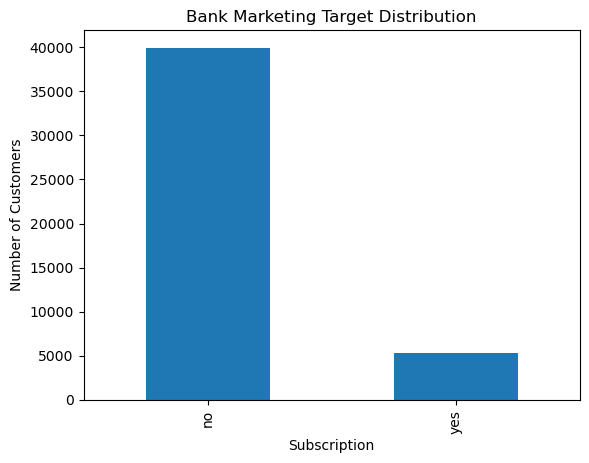

In [10]:
data['y'].value_counts().plot(kind='bar')

plt.title("Bank Marketing Target Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")
plt.show()

In [11]:
data['y'] = data['y'].map({'no': 0, 'yes': 1})

print(data['y'].value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


In [12]:
X = data.drop(['y', 'duration'], axis=1)
y = data['y']

In [13]:
print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome'],
      dtype='object')

Target:
y


In [14]:
X = pd.get_dummies(X, drop_first=True)

In [15]:
print("Number of features after encoding:", X.shape[1])

X.head()

Number of features after encoding: 41


,age,balance,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,1,-1,0,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,1,-1,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,1,-1,0,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,1,-1,0,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,1,-1,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (33908, 41)
Testing data: (11303, 41)


In [17]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=0
)

random_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
y_pred_rf = random_forest.predict(X_test)

In [24]:
# Random Forest evaluation

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest F1-score:", rf_f1)

Random Forest Accuracy: 0.8916216933557463
Random Forest Precision: 0.6047516198704104
Random Forest Recall: 0.2118003025718608
Random Forest F1-score: 0.3137254901960784


In [25]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      9981
           1       0.60      0.21      0.31      1322

    accuracy                           0.89     11303
   macro avg       0.75      0.60      0.63     11303
weighted avg       0.87      0.89      0.87     11303



In [26]:
rf_cm = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[9798  183]
 [1042  280]]


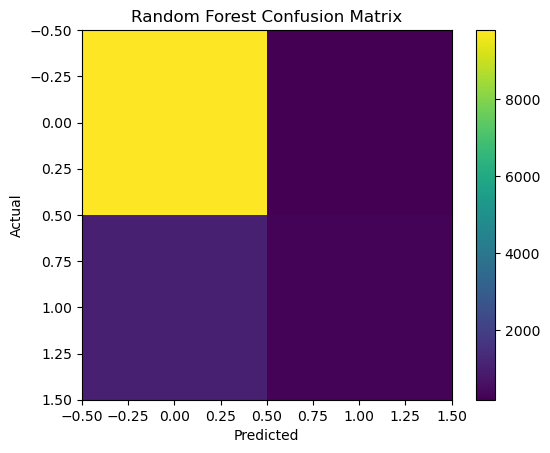

In [27]:
plt.imshow(rf_cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.show()

In [28]:
feature_importance = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
balance                0.183576
age                    0.154454
day                    0.132358
campaign               0.061319
poutcome_success       0.055561
pdays                  0.050589
previous               0.025017
housing_yes            0.021917
education_secondary    0.018348
marital_married        0.014833
dtype: float64


In [31]:
# SVM
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
svm_model = SVC(
    kernel='rbf',
    random_state=0
)

svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [33]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [34]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)
print("SVM Precision:", svm_precision)
print("SVM Recall:", svm_recall)
print("SVM F1-score:", svm_f1)

SVM Accuracy: 0.8933026630098204
SVM Precision: 0.645
SVM Recall: 0.1951588502269289
SVM F1-score: 0.29965156794425085


In [35]:
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      9981
           1       0.65      0.20      0.30      1322

    accuracy                           0.89     11303
   macro avg       0.77      0.59      0.62     11303
weighted avg       0.87      0.89      0.87     11303



In [36]:
svm_cm = confusion_matrix(y_test, y_pred_svm)

print("SVM Confusion Matrix:")
print(svm_cm)

SVM Confusion Matrix:
[[9839  142]
 [1064  258]]


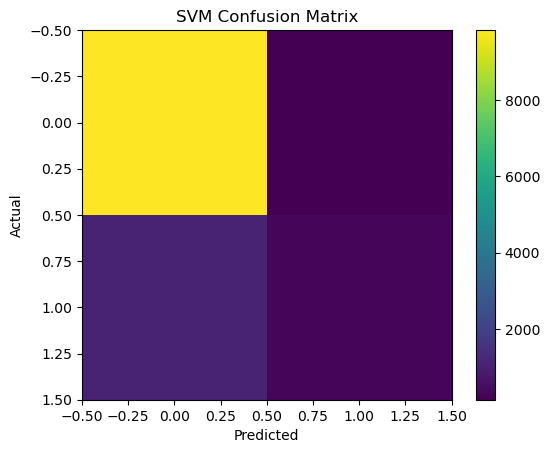

In [37]:
plt.imshow(svm_cm)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.show()

In [38]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'SVM'],
    'Accuracy': [rf_accuracy, svm_accuracy],
    'Precision': [rf_precision, svm_precision],
    'Recall': [rf_recall, svm_recall],
    'F1-score': [rf_f1, svm_f1]
})

print(results)

           Model  Accuracy  Precision    Recall  F1-score
0  Random Forest  0.891622   0.604752  0.211800  0.313725
1            SVM  0.893303   0.645000  0.195159  0.299652


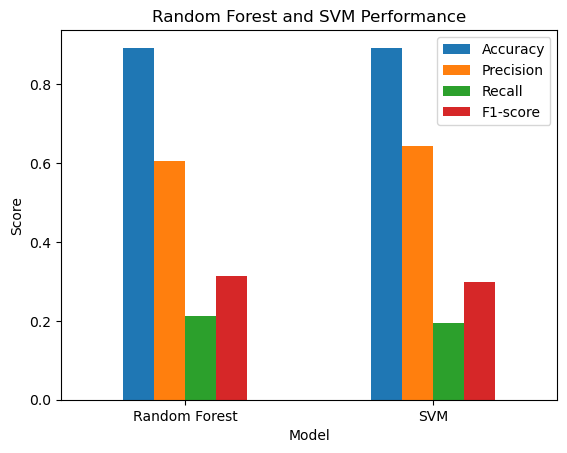

In [39]:
results.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1-score'
]].plot(kind='bar')

plt.title("Random Forest and SVM Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

In [41]:
print(y_test.value_counts())
print(classification_report(y_test, y_pred_rf))

y
0    9981
1    1322
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      9981
           1       0.60      0.21      0.31      1322

    accuracy                           0.89     11303
   macro avg       0.75      0.60      0.63     11303
weighted avg       0.87      0.89      0.87     11303

